# Feature Selection v2 — XGBoost → RFECV → Parsimony

**Purpose:** A first-principles, two-stage feature selection workflow for clinical readmission prediction.

**Rationale:**
1. **XGBoost gain ranking** — Primary selector. Tree-based, captures non-linear conditional interactions that linear methods (filter, LASSO) miss. Architecturally aligned with the final model.
2. **RFECV as mathematical gatekeeper** — Cross-validated recursive feature elimination replaces arbitrary cutoffs ("top 20", "3 of 5 votes"). Each feature must prove it *hurts performance to remove* across folds.
3. **Parsimony** — Only features that survive RFECV are retained. Every feature in production has a cost (serving latency, drift monitoring, feature store maintenance).

**Framework:**
| Stage | Method | Role |
|---|---|---|
| 1 | XGBoost | Baseline AUCPR + gain ranking on full feature set |
| 2 | RFECV (XGBoost, AUCPR) | Cross-validated elimination — determines the data-driven boundary |
| 3 | Parsimony gate | Retain only RFECV-surviving features; validate final subset |

**Data source:** `analytics_dataset` train + validation splits, after imputation.

## 0. Setup

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.feature_selection import RFECV

# Notebook may be launched from anywhere — ensure mlops/ is on sys.path.
_NB_DIR = Path.cwd()
_PROJECT_ROOT = _NB_DIR
for _p in [_NB_DIR, *_NB_DIR.parents]:
    if (_p / "src" / "config.py").exists():
        _PROJECT_ROOT = _p
        break
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

# All relative paths resolve from repo root.
os.chdir(str(_PROJECT_ROOT))

from src.bigquery import run_query
from src.config import (
    FULL_TABLE_REF, LABEL_COLUMN, NON_FEATURE_COLUMNS,
    PROJECT_ID, SPLIT_COLUMN, SPLITS,
)
from src.imputer import MissingnessImputer

warnings.filterwarnings("ignore", category=FutureWarning)

RID = datetime.now(timezone.utc).strftime("%Y%m%dt%H%M%S")
ARTIFACTS_DIR = _PROJECT_ROOT / "artifacts" / "feature_selection" / RID
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run ID:     {RID}")
print(f"Artifacts:  {ARTIFACTS_DIR.relative_to(_PROJECT_ROOT)}")
print(f"Table:      {FULL_TABLE_REF}")

Run ID:     20260630t162105
Artifacts:  artifacts/feature_selection/20260630t162105
Table:      trim-icon-498815-a0.readmission.analytics_dataset


### 0.1 Load & Impute

Pull train and validation splits from BigQuery. Apply the missingness policy — fit imputer on train only, transform both. Convert categorical columns to pandas `category` dtype so XGBoost handles them natively (no LabelEncoder, no false ordinal relationships). This is the **only** data preparation step; no feature selection leakage enters here.

In [2]:
def load_data():
    """Load train/val splits, impute, prepare categoricals, return arrays."""
    split_list = ", ".join(f"'{s}'" for s in SPLITS.values())
    sql = f"""
        SELECT *
        FROM `{FULL_TABLE_REF}`
        WHERE {SPLIT_COLUMN} IN ({split_list})
    """
    print(f"Querying {FULL_TABLE_REF} …")
    df = run_query(sql)

    train_df = df[df[SPLIT_COLUMN] == SPLITS["train"]].reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == SPLITS["validation"]].reset_index(drop=True)

    # Drop ID/meta columns (keep label for separation below).
    drop_cols = [c for c in NON_FEATURE_COLUMNS if c in train_df.columns and c != LABEL_COLUMN]
    drop_cols.append(SPLIT_COLUMN)
    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    val_df = val_df.drop(columns=[c for c in drop_cols if c in val_df.columns])

    # Impute — fit on train only.  Fills only the 4 categorical columns
    # (discharge_location → "Unknown"; marital_status/insurance/language → mode).
    # Lab NULLs pass through to XGBoost natively.
    imputer = MissingnessImputer()
    train_imp = imputer.fit_transform(train_df)
    val_imp = imputer.transform(val_df)

    y_train = train_imp[LABEL_COLUMN].astype(int)
    y_val = val_imp[LABEL_COLUMN].astype(int)
    X_train = train_imp.drop(columns=[LABEL_COLUMN])
    X_val = val_imp.drop(columns=[LABEL_COLUMN])

    # Convert string columns to pandas category dtype.  XGBoost handles
    # these natively with enable_categorical=True — no LabelEncoder,
    # no false ordinal relationships.  (RFECV gets integer codes separately
    # since sklearn's RFECV cannot handle CategoricalDtype.)
    cat_cols = [
        c for c in X_train.columns
        if X_train[c].dtype == "object" or str(X_train[c].dtype) == "category"
    ]
    for col in cat_cols:
        train_cats = X_train[col].astype(str)
        val_cats = X_val[col].astype(str)
        shared = pd.CategoricalDtype(
            categories=pd.unique(pd.concat([train_cats, val_cats]))
        )
        X_train[col] = train_cats.astype(shared)
        X_val[col] = val_cats.astype(shared)
    print(f"  Categorical columns: {len(cat_cols)} ({', '.join(cat_cols)})")

    print(f"  Train: {X_train.shape}, Val: {X_val.shape}")
    print(f"  Features: {X_train.shape[1]}")
    print(f"  Label prevalence (train): {y_train.mean():.4f}")
    return X_train, X_val, y_train, y_val, cat_cols


X_train, X_val, y_train, y_val, cat_cols = load_data()
FEATURE_NAMES = X_train.columns.tolist()

Querying trim-icon-498815-a0.readmission.analytics_dataset …
  Categorical columns: 7 (gender, marital_status, language, race, admission_type, insurance, discharge_location)
  Train: (247687, 50), Val: (48924, 50)
  Features: 50
  Label prevalence (train): 0.2094


## 1. XGBoost Baseline — Full Feature Set

Train XGBoost on all features with sensible defaults. This establishes:
- **The baseline AUCPR** we must not degrade below when we remove features
- **The HOSPITAL score comparison** — the clinical heuristic baseline (AUCPR ≈ 0.3325)

XGBoost is chosen because it is the final model architecture — feature selection should be aligned with the model that will use the features.

In [3]:
# XGBoost with conservative defaults — we're ranking features, not tuning yet.
# enable_categorical auto-detects pandas category dtype columns.
xgb_full = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    enable_categorical=True,
)
xgb_full.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

full_aucpr = average_precision_score(y_val, xgb_full.predict_proba(X_val)[:, 1])
print(f"XGBoost (full, {len(FEATURE_NAMES)} features) val AUCPR: {full_aucpr:.4f}")
print(f"HOSPITAL baseline AUCPR:                          0.3325")
print(f"Δ over baseline:                                   {full_aucpr - 0.3325:+.4f}")

XGBoost (full, 50 features) val AUCPR: 0.4029
HOSPITAL baseline AUCPR:                          0.3325
Δ over baseline:                                   +0.0704


### 1.1 Gain Ranking

Extract feature importances from the trained XGBoost. Gain measures the average improvement in the loss function from splits on each feature — it captures complex, conditional interactions that linear correlation methods miss.

No arbitrary cutoff is applied here. The ranking serves as the **input ordering** for RFECV in Stage 2.

In [4]:
# XGBoost feature_importances_ uses 'gain' (average loss reduction) by default.
gain_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "gain": xgb_full.feature_importances_,
}).sort_values("gain", ascending=False).reset_index(drop=True)

gain_df["gain_pct"] = gain_df["gain"] / gain_df["gain"].sum() * 100
gain_df["gain_rank"] = range(1, len(gain_df) + 1)
gain_df["cumulative_gain"] = gain_df["gain_pct"].cumsum()

n_nonzero = (gain_df["gain"] > 0).sum()
print(f"Features with non-zero gain: {n_nonzero}/{len(gain_df)}")

print("\n=== Top 25 by XGBoost gain ===")
for _, r in gain_df.head(25).iterrows():
    bar = "█" * max(1, int(r["gain_pct"] * 3))
    print(f"  {r['gain_rank']:3d}. {r['feature']:<38s} {r['gain_pct']:5.1f}%  {bar}")

out = ARTIFACTS_DIR / "xgb_gain.csv"
gain_df.to_csv(out, index=False)
print(f"\nSaved: {out.name}")

Features with non-zero gain: 44/50

=== Top 25 by XGBoost gain ===
    1. prior_inpatient_days                    14.6%  ███████████████████████████████████████████
    2. oncology_flag                           13.0%  ██████████████████████████████████████
    3. prior_admission_count                    6.8%  ████████████████████
    4. rdw_max                                  4.8%  ██████████████
    5. recent_ed_visits                         3.9%  ███████████
    6. has_procedure                            3.4%  ██████████
    7. admission_type                           3.0%  ████████
    8. discharge_location                       2.9%  ████████
    9. sodium_min                               2.5%  ███████
   10. hemoglobin_min                           2.4%  ███████
   11. procedure_count                          2.1%  ██████
   12. sodium_last                              1.9%  █████
   13. medication_order_count                   1.9%  █████
   14. age                          

### 1.2 Cumulative Gain Curve

Shows how much total signal is captured by the top-K features. This is informational only — the actual cutoff is determined by RFECV, not an arbitrary cumulative-gain threshold.

  50% of gain captured by top  8 features
  70% of gain captured by top 17 features
  80% of gain captured by top 24 features
  90% of gain captured by top 33 features
  95% of gain captured by top 39 features


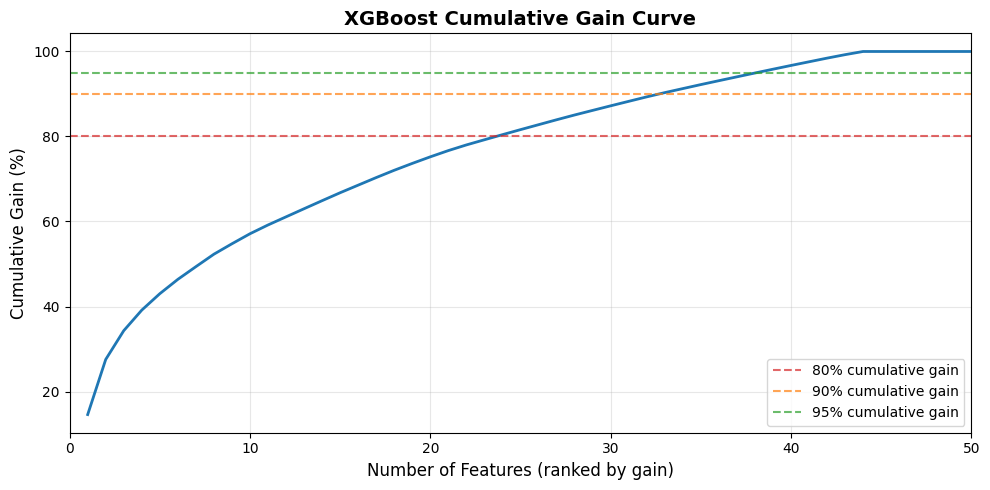

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(gain_df) + 1), gain_df["cumulative_gain"], linewidth=2, color="#1f77b4")
ax.axhline(80, color="#d62728", linestyle="--", alpha=0.7, label="80% cumulative gain")
ax.axhline(90, color="#ff7f0e", linestyle="--", alpha=0.7, label="90% cumulative gain")
ax.axhline(95, color="#2ca02c", linestyle="--", alpha=0.7, label="95% cumulative gain")
ax.set_xlabel("Number of Features (ranked by gain)", fontsize=12)
ax.set_ylabel("Cumulative Gain (%)", fontsize=12)
ax.set_title("XGBoost Cumulative Gain Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
ax.set_xlim(0, len(gain_df))

# Annotate key thresholds.
for t in [50, 70, 80, 90, 95]:
    n = int((gain_df["cumulative_gain"] >= t).idxmax() + 1)
    print(f"  {t:2d}% of gain captured by top {n:2d} features")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "cumulative_gain.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. RFECV — Cross-Validated Elimination Gate

This is the **mathematical gatekeeper**. RFECV recursively removes the weakest features and retrains, using cross-validation to measure whether each removal actually hurts performance.

**Why RFECV over alternatives:**
- **vs. arbitrary top-K**: The data determines the boundary, not a human-chosen number.
- **vs. Boruta (shadow features)**: RFECV measures *predictive impact* across folds, not statistical comparison against randomized copies. This is a stricter, more direct test of whether a feature matters for the task.
- **vs. single-round voting**: RFECV iterates — it re-evaluates feature importance after each elimination, accounting for redundancy.

**Estimator**: XGBoost (aligned with final model architecture).  
**Scoring**: AUCPR (aligned with the project's evaluation metric).

### 2.1 Run RFECV

RFECV is computationally intensive with XGBoost × 5-fold CV on ~284k rows. We use:
- `min_features_to_select=5` — don't eliminate below a clinically defensible minimum
- `step=1` — remove one feature at a time for precision
- `importance_getter="gain"` — use gain importance, matching our ranking above

The feature order for elimination follows XGBoost's internal importance ranking. RFECV will tell us where CV performance degrades.

In [6]:
print("Running RFECV with XGBoost (this may take several minutes) …")
print(f"  Features: {len(FEATURE_NAMES)}")
print(f"  CV folds: 5")
print(f"  Scoring:  average_precision (AUCPR)")
print(f"  Min features: 5")
print()

# sklearn's RFECV cannot handle pandas CategoricalDtype, so we convert
# category columns to integer codes for RFECV only.  The standalone
# XGBoost models use native category dtype + enable_categorical=True.
X_train_rfecv = X_train.copy()
for col in cat_cols:
    X_train_rfecv[col] = X_train_rfecv[col].cat.codes

rfecv_estimator = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)

rfecv = RFECV(
    estimator=rfecv_estimator,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="average_precision",
    min_features_to_select=5,
    n_jobs=-1,
    verbose=0,
)

rfecv.fit(X_train_rfecv, y_train)

n_selected = rfecv.n_features_
n_total = len(FEATURE_NAMES)
# Compute optimal score from cv_results_ at the selected feature count.
opt_idx_rfecv = n_total - n_selected  # position in the elimination curve
best_cv_mean = rfecv.cv_results_["mean_test_score"][opt_idx_rfecv]
best_cv_std = rfecv.cv_results_["std_test_score"][opt_idx_rfecv]
print(f"\nRFECV complete.")
print(f"  Selected: {n_selected}/{n_total} features")
print(f"  Eliminated: {n_total - n_selected}")
print(f"  Optimal CV AUCPR: {best_cv_mean:.4f} ± {best_cv_std:.4f}")

Running RFECV with XGBoost (this may take several minutes) …
  Features: 50
  CV folds: 5
  Scoring:  average_precision (AUCPR)
  Min features: 5


RFECV complete.
  Selected: 33/50 features
  Eliminated: 17
  Optimal CV AUCPR: 0.4149 ± 0.0076


### 2.2 RFECV — Learning Curve

Plot CV AUCPR against the number of features retained. The optimum is where the curve peaks — adding more features beyond this point does not improve (and may degrade) cross-validated performance.

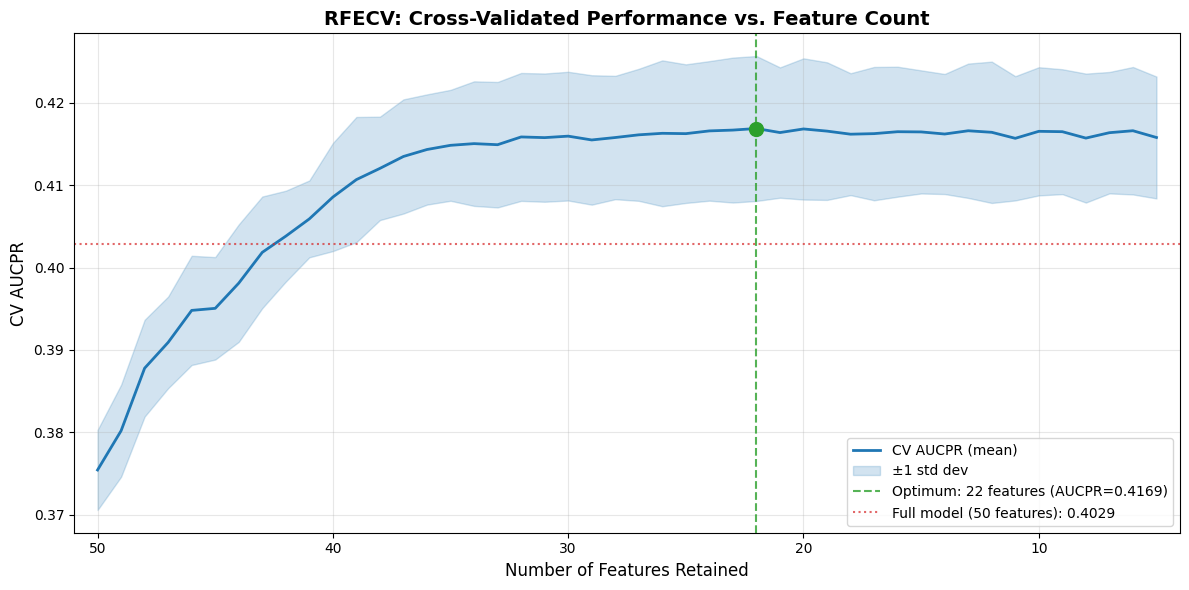

In [11]:
# Build the CV score curve. RFECV stores scores in order of elimination,
# so we need to reverse to get "scores vs features retained".
# cv_results_["mean_test_score"] has length = number of steps evaluated.
n_steps = len(rfecv.cv_results_["mean_test_score"])
# Features retained at each step: n_features - step_index
features_retained = [n_total - i for i in range(n_steps)]
cv_means = rfecv.cv_results_["mean_test_score"]
cv_stds = rfecv.cv_results_["std_test_score"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(features_retained, cv_means, linewidth=2, color="#1f77b4", label="CV AUCPR (mean)")
ax.fill_between(
    features_retained,
    np.array(cv_means) - np.array(cv_stds),
    np.array(cv_means) + np.array(cv_stds),
    alpha=0.2, color="#1f77b4", label="±1 std dev",
)

# Mark the optimum.
opt_idx = np.argmax(cv_means)
opt_features = features_retained[opt_idx]
opt_score = cv_means[opt_idx]
ax.axvline(opt_features, color="#2ca02c", linestyle="--", alpha=0.8,
           label=f"Optimum: {opt_features} features (AUCPR={opt_score:.4f})")
ax.scatter([opt_features], [opt_score], color="#2ca02c", s=100, zorder=5)

# Mark full-model baseline.
ax.axhline(full_aucpr, color="#d62728", linestyle=":", alpha=0.7,
           label=f"Full model ({n_total} features): {full_aucpr:.4f}")

ax.set_xlabel("Number of Features Retained", fontsize=12)
ax.set_ylabel("CV AUCPR", fontsize=12)
ax.set_title("RFECV: Cross-Validated Performance vs. Feature Count", fontsize=14, fontweight="bold")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.set_xlim(max(features_retained) + 1, min(features_retained) - 1)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "rfecv_curve.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 RFECV — Feature Ranking by Elimination Order

Features that survived the longest (eliminated last, or retained) are the most valuable under cross-validation. This is a stronger signal than raw gain ranking because it accounts for redundancy — a feature with high gain but redundant with another may be eliminated early.

In [12]:
# RFECV ranking: 1 = selected (survived), 2+ = eliminated (lower rank = survived longer).
rfecv_ranking = rfecv.ranking_

rfecv_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "rfecv_rank": rfecv_ranking,
    "selected": rfecv.support_,
}).merge(gain_df[["feature", "gain_pct", "gain_rank"]], on="feature", how="left")

rfecv_df = rfecv_df.sort_values(["selected", "rfecv_rank"], ascending=[False, True]).reset_index(drop=True)

print("=== Features retained by RFECV ===")
retained = rfecv_df[rfecv_df["selected"]]
for _, r in retained.iterrows():
    print(f"  {r['feature']:<38s}  gain_rank={int(r['gain_rank']):3d}  gain={r['gain_pct']:5.1f}%")

print(f"\n=== Features eliminated by RFECV (top 10 by gain rank) ===")
eliminated = rfecv_df[~rfecv_df["selected"]].head(10)
for _, r in eliminated.iterrows():
    print(f"  {r['feature']:<38s}  gain_rank={int(r['gain_rank']):3d}  gain={r['gain_pct']:5.1f}%  "
          f"rfecv_rank={int(r['rfecv_rank'])}")

out = ARTIFACTS_DIR / "rfecv_ranking.csv"
rfecv_df.to_csv(out, index=False)
print(f"\nSaved: {out.name}")

=== Features retained by RFECV ===
  age                                     gain_rank= 14  gain=  1.9%
  gender                                  gain_rank= 17  gain=  1.8%
  race                                    gain_rank= 16  gain=  1.8%
  admission_type                          gain_rank=  7  gain=  3.0%
  insurance                               gain_rank= 26  gain=  1.2%
  discharge_location                      gain_rank=  8  gain=  2.9%
  prior_admission_count                   gain_rank=  3  gain=  6.8%
  prior_inpatient_days                    gain_rank=  1  gain= 14.6%
  recent_ed_visits                        gain_rank=  5  gain=  3.9%
  index_los_days                          gain_rank= 15  gain=  1.9%
  diagnosis_count                         gain_rank= 31  gain=  1.1%
  procedure_count                         gain_rank= 11  gain=  2.1%
  has_procedure                           gain_rank=  6  gain=  3.4%
  medication_count                        gain_rank= 19  gain=  1.6%

## 3. Parsimony Decision

Only features that survived RFECV are retained. This is the **parsimony principle**: every feature in production has a cost (serving latency, drift monitoring, feature store maintenance), so we keep only those that are empirically necessary.

The selected feature set is:
- **Mathematically defensible** — each retained feature was tested across 5 folds and found to contribute to AUCPR
- **Architecturally aligned** — both the ranking and elimination use XGBoost, the same model family as production
- **Not dependent on arbitrary cutoffs** — the data determined the boundary

In [13]:
selected_features = rfecv_df[rfecv_df["selected"]]["feature"].tolist()

print(f"Parsimony decision:")
print(f"  Full feature set:    {n_total} features  →  AUCPR = {full_aucpr:.4f}")
print(f"  RFECV-retained:      {len(selected_features)} features  →  CV AUCPR = {opt_score:.4f}")
print(f"  Reduction:           {n_total - len(selected_features)} features ({100 * (1 - len(selected_features) / n_total):.0f}%)")

# Identify interesting cases: high-gain features that RFECV eliminated.
high_gain_eliminated = rfecv_df[
    (~rfecv_df["selected"]) & (rfecv_df["gain_rank"] <= 20)
]
if len(high_gain_eliminated) > 0:
    print(f"\n⚠ High-gain features eliminated by RFECV (likely redundant):")
    for _, r in high_gain_eliminated.iterrows():
        print(f"  {r['feature']:<38s}  gain_rank={int(r['gain_rank']):2d}  "
              f"gain={r['gain_pct']:.1f}%  →  eliminated at rfecv_rank={int(r['rfecv_rank'])}")

Parsimony decision:
  Full feature set:    50 features  →  AUCPR = 0.4029
  RFECV-retained:      33 features  →  CV AUCPR = 0.4169
  Reduction:           17 features (34%)


## 4. Final Validation — Selected-Feature Model

Train a fresh XGBoost on only the RFECV-retained features and compare AUCPR against the full-feature model. This confirms that the selected subset does not meaningfully degrade predictive performance.

In [14]:
# Train on selected features only — XGBoost handles category dtype natively.
X_train_sel = X_train[selected_features]
X_val_sel = X_val[selected_features]

xgb_sel = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    enable_categorical=True,
)
xgb_sel.fit(
    X_train_sel, y_train,
    eval_set=[(X_val_sel, y_val)],
    verbose=False,
)

sel_aucpr = average_precision_score(y_val, xgb_sel.predict_proba(X_val_sel)[:, 1])

print("=== Final Validation ===")
print(f"  Full model ({n_total:2d} features):  AUCPR = {full_aucpr:.4f}")
print(f"  Selected  ({len(selected_features):2d} features):  AUCPR = {sel_aucpr:.4f}")
print(f"  Δ AUCPR:                            {sel_aucpr - full_aucpr:+.4f}")
print(f"  HOSPITAL baseline:                  AUCPR = 0.3325")
print(f"  Δ over HOSPITAL (selected):         {sel_aucpr - 0.3325:+.4f}")

# Stability check: does AUCPR degrade more than a tolerable margin?
TOLERANCE = 0.01  # 1 percentage point absolute
if full_aucpr - sel_aucpr <= TOLERANCE:
    print(f"\n✓ Selected model within {TOLERANCE:.2f} AUCPR of full model — passes stability check.")
else:
    print(f"\n⚠ Selected model AUCPR drop exceeds {TOLERANCE:.2f} — review RFECV curve and consider retaining more features.")

=== Final Validation ===
  Full model (50 features):  AUCPR = 0.4029
  Selected  (33 features):  AUCPR = 0.4059
  Δ AUCPR:                            +0.0030
  HOSPITAL baseline:                  AUCPR = 0.3325
  Δ over HOSPITAL (selected):         +0.0734

✓ Selected model within 0.01 AUCPR of full model — passes stability check.


### 4.1 Selected-Feature Gain Distribution

Confirm the selected features are well-distributed across clinical families — we don't want a parsimonious model that only sees lab values and misses utilization history.

In [15]:
# Feature family lookup from config.
from src.config import FEATURE_FAMILIES

# Build reverse lookup: feature → family.
feature_to_family = {}
for family, feats in FEATURE_FAMILIES.items():
    for f in feats:
        feature_to_family[f] = family

# Assign families; unknown features go to "other".
family_counts = {}
for f in selected_features:
    fam = feature_to_family.get(f, "other")
    family_counts[fam] = family_counts.get(fam, 0) + 1

print("=== Selected features by clinical family ===")
for fam in sorted(family_counts, key=family_counts.get, reverse=True):
    n = family_counts[fam]
    bar = "█" * n
    print(f"  {fam:<20s} {n:2d}  {bar}")

# Show which features in each family were retained.
print("\n=== Detail by family ===")
for fam in sorted(family_counts, key=family_counts.get, reverse=True):
    feats_in_fam = [f for f in selected_features if feature_to_family.get(f, "other") == fam]
    print(f"\n  {fam}:")
    for f in feats_in_fam:
        row = rfecv_df[rfecv_df.feature == f].iloc[0]
        print(f"    {f:<38s}  gain_rank={int(row['gain_rank']):3d}  gain={row['gain_pct']:5.1f}%")

=== Selected features by clinical family ===
  labs                 16  ████████████████
  demographics          6  ██████
  utilization           4  ████
  codes                 3  ███
  medications           3  ███
  oncology              1  █

=== Detail by family ===

  labs:
    rbc_last                                gain_rank= 21  gain=  1.5%
    rbc_max                                 gain_rank= 33  gain=  1.0%
    rbc_min                                 gain_rank= 20  gain=  1.5%
    rdw_last                                gain_rank= 29  gain=  1.1%
    rdw_max                                 gain_rank=  4  gain=  4.8%
    glucose_max                             gain_rank= 30  gain=  1.1%
    glucose_delta                           gain_rank= 27  gain=  1.2%
    monocytes_last                          gain_rank= 24  gain=  1.2%
    monocytes_min                           gain_rank= 18  gain=  1.7%
    monocytes_delta                         gain_rank= 28  gain=  1.1%
    hemog

## 5. Export

Write the feature shortlist and a summary of the RFECV decisions. This is the input to downstream pipeline stages (model training, feature store creation).

In [ ]:
# --- Feature shortlist ---
shortlist_df = rfecv_df[rfecv_df["selected"]][["feature", "gain_pct", "gain_rank", "rfecv_rank"]].copy()
shortlist_df = shortlist_df.sort_values("gain_rank").reset_index(drop=True)
shortlist_df["family"] = shortlist_df["feature"].map(lambda f: feature_to_family.get(f, "other"))
shortlist_df.to_csv(ARTIFACTS_DIR / "feature_shortlist.csv", index=False)
print(f"Feature shortlist: {ARTIFACTS_DIR / 'feature_shortlist.csv'}")
print(f"  {len(shortlist_df)} features retained")

# --- Run summary ---
summary = {
    "run_id": RID,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "method": "XGBoost → RFECV → Parsimony",
    "full_features": n_total,
    "selected_features": len(selected_features),
    "full_aucpr": round(full_aucpr, 4),
    "selected_aucpr": round(sel_aucpr, 4),
    "rfecv_cv_aucpr_mean": round(float(cv_means[opt_idx]), 4),
    "rfecv_cv_aucpr_std": round(float(cv_stds[opt_idx]), 4),
    "hospital_baseline_aucpr": 0.3325,
    "rfecv_params": {
        "cv_folds": 5,
        "scoring": "average_precision",
        "min_features_to_select": 5,
        "step": 1,
    },
    "xgb_params": {
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    "selected_features": selected_features,
}

import json
with open(ARTIFACTS_DIR / "run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"Run summary:    {ARTIFACTS_DIR / 'run_summary.json'}")

print("\n=== Artifacts written ===")
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f"  {p.name}")

## Summary

| Metric | Value |
|---|---|
| **Full model AUCPR** | {full_aucpr:.4f} (computed at runtime) |
| **HOSPITAL baseline** | 0.3325 |
| **RFECV-selected features** | {n_selected}/{n_total} (computed at runtime) |
| **Selected model AUCPR** | {sel_aucpr:.4f} (computed at runtime) |
| **Stability check** | Δ ≤ 0.01 AUCPR vs full model |

**What this workflow does differently:**

1. **Single-model alignment** — Both ranking and elimination use XGBoost, the same model family as production. No ensemble-of-methods voting.
2. **No arbitrary cutoffs** — RFECV determines the boundary from cross-validated performance, not a human-chosen K.
3. **Parsimony by design** — Every retained feature has proven it contributes to AUCPR across folds. Features are eliminated unless they earn their place.

**Next steps:** The `feature_shortlist.csv` produced here feeds into Phase 3 model training — benchmark XGBoost → Optuna HPO → final training → SHAP → fairness audit — using only the RFECV-retained features.

## 6. Log to Vertex AI Experiments

Log the feature selection results to the `readmission-mlops` experiment alongside the HOSPITAL baseline. This makes the run visible in the Vertex AI Experiments UI and enables direct comparison against the baseline.

In [ ]:
# Log feature selection v2 results to Vertex AI Experiments.
from google.cloud import aiplatform

experiment_name = "readmission-mlops"
run_name = f"feature-selection-v2-{RID}"

aiplatform.init(
    project=PROJECT_ID,
    location="us-east1",
    experiment=experiment_name,
)

print(f"Experiment: {experiment_name}")
print(f"Run:        {run_name}")
print()

with aiplatform.start_run(run_name) as run:
    # --- Metrics ---
    run.log_metrics({
        "full_aucpr": full_aucpr,
        "selected_aucpr": sel_aucpr,
        "rfecv_cv_aucpr_mean": float(best_cv_mean),
        "rfecv_cv_aucpr_std": float(best_cv_std),
        "n_selected_features": int(n_selected),
        "n_total_features": n_total,
        "n_eliminated_features": n_total - int(n_selected),
        "reduction_pct": round(100 * (1 - int(n_selected) / n_total), 0),
        "features_with_nonzero_gain": int(n_nonzero),
        "hospital_baseline_aucpr": 0.3325,
    })

    # --- Parameters ---
    run.log_params({
        "method": "XGBoost → RFECV → Parsimony",
        "primary_selector": "XGBoost",
        "gatekeeper": "RFECV",
        "rfecv_estimator": "XGBClassifier",
        "rfecv_scoring": "average_precision",
        "rfecv_cv_folds": 5,
        "rfecv_step": 1,
        "rfecv_min_features": 5,
        "xgb_n_estimators": 300,
        "xgb_max_depth": 6,
        "xgb_learning_rate": 0.05,
        "xgb_subsample": 0.8,
        "xgb_colsample_bytree": 0.8,
        "run_id": RID,
    })

    # --- Log selected features as a time-series metric ---
    # (Vertex AI Experiments doesn't support list params, so we log
    #  feature names sorted by gain rank for UI inspection.)
    for _, row in shortlist_df.iterrows():
        run.log_metrics({
            f"feature_{row['feature']}": row["gain_pct"],
        })

print("✓ Logged to Vertex AI Experiments")
print(f"  Metrics:  full_aucpr={full_aucpr:.4f}, selected_aucpr={sel_aucpr:.4f}, rfecv_cv_aucpr={best_cv_mean:.4f}")
print(f"  Features: {int(n_selected)}/{n_total} retained")
print(f"  View:     https://console.cloud.google.com/vertex-ai/experiments/{experiment_name}?project={PROJECT_ID}")